## Problem statement
Given a path observed from a stochastic process modeled by
$$

dS_t = \mu S_t dt + \sigma S_t dB_t

$$
We aim to estimate the parameters such as $\mu$ and $\sigma$. Now let's do some math, suppose we observed $S_{t_{i}}$, we need to find $\hat{\mu}$ and $\hat{\sigma}$. We know that
$$
\ln S_{t_{i + 1}} - \ln S_{t} = \left( \mu-\frac{\sigma^2}{2} \right)\Delta _{t} + \sigma B_{\Delta_{t}}
$$
where $\Delta_{t} = t_{i + 1} - t_{i}$ and $B_{\Delta_{t}} \sim N(0, \Delta_{t})$. 
## Solution
Suppose $\Delta_{t}$ is the same for all $i$, there are certain things that we can do here. The easiest thing we can do is to take the mean of the observed value, that would give $\mu - \frac{\sigma^2}{2}$ easily. Then we estimate the variance. So the parameter estimation here is just robust statistic. 


In [96]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [16]:

def generate_gbm_paths(S0, mu, sigma, T, N, M, mesh_size=1e-3):
    dt = mesh_size
    num_steps = int(T / dt)
    paths = np.zeros((M, num_steps + 1))
    paths[:, 0] = S0
    for i in range(1, num_steps + 1):
        Z = np.random.standard_normal(M)
        paths[:, i] = paths[:, i - 1] + paths[:, i - 1] * mu * dt + paths[:, i - 1] * sigma * np.sqrt(dt) * Z
    # Only return exactly N time steps spaced out evenly over the interval [0, T]
    step_indices = np.linspace(0, num_steps, N + 1, dtype=int)
    return paths[:, step_indices]

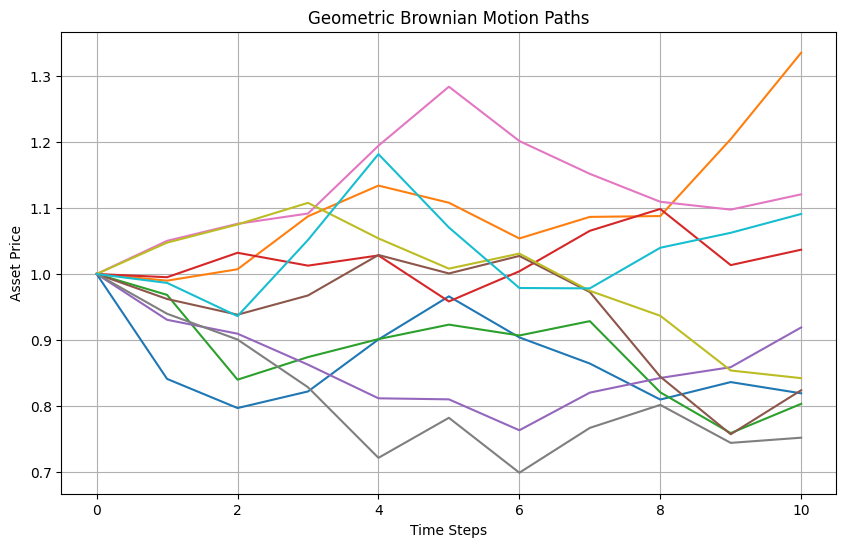

In [23]:
paths = generate_gbm_paths(S0=1, mu=0.1, sigma=0.2, T=1, N=10, M=10)
# Plot the paths
plt.figure(figsize=(10, 6))
for i in range(paths.shape[0]):
    plt.plot(paths[i], label=f'Path {i+1}')
plt.title('Geometric Brownian Motion Paths')
plt.xlabel('Time Steps')
plt.ylabel('Asset Price')
plt.grid()
plt.show()

In [28]:
def path_wise_gbm_parameter_estimation(paths, T):
    N = paths.shape[1] - 1  # Number of time steps
    dt = T / N
    mu_estimates = []
    sigma_estimates = []
    
    for path in paths:
        log_returns = np.diff(np.log(path))
        sampled_variance = np.var(log_returns, ddof=1)
        mu_hat = np.mean(log_returns) / dt + (sampled_variance / (2 * dt))
        sigma_hat = np.sqrt(sampled_variance / dt)
        mu_estimates.append(mu_hat)
        sigma_estimates.append(sigma_hat)
    
    return np.array(mu_estimates), np.array(sigma_estimates)

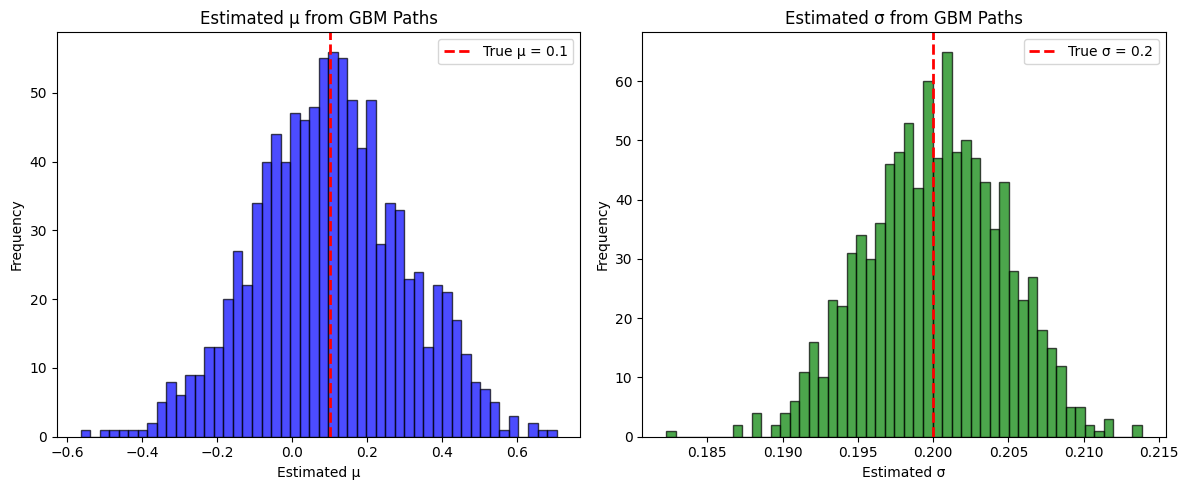

In [84]:
true_mu = 0.1
true_sigma = 0.2
paths = generate_gbm_paths(S0=1, mu=true_mu, sigma=true_sigma, T=1, N=1000, M=1000, mesh_size=1e-4)
estimated_mu, estimated_sigma = path_wise_gbm_parameter_estimation(paths, T=1)
# Plot the histogram of estimated parameters and mark the true values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(estimated_mu, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(true_mu, color='red', linestyle='dashed', linewidth=2, label=f'True μ = {true_mu}')
plt.title('Estimated μ from GBM Paths')
plt.xlabel('Estimated μ')
plt.ylabel('Frequency')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(estimated_sigma, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.axvline(true_sigma, color='red', linestyle='dashed', linewidth=2, label=f'True σ = {true_sigma}')
plt.title('Estimated σ from GBM Paths')
plt.xlabel('Estimated σ')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

So far we can say that the estimator is unbiased. We can run the block above multiple times to realize that if we rely on a single path to estimate the parameters, the error is large, in other words, the variance is big. I wonder what's the distribution of the estimated parameters?

Let us define $X = \ln S_{t_{i + 1}} - \ln {S_{t}}$, then
$$
\begin{align}
\hat{\mu}_{X} = \sum_{i} \frac{X_{i}}{N} \quad \hat{\sigma}^2_{X} = \sum_{i} \frac{(X_{i} - \hat{\mu}_{X})^2}{N - 1} \\
\mu = \frac{\mu_{X}}{\Delta_{t}} + \frac{\sigma^2_{X}}{2\Delta_{t}} \quad \sigma = \frac{\sigma_{X}}{\sqrt{ \Delta_{t} }} \\ \\
\hat{\mu} = \frac{\hat{\mu}_{X}  + \hat{\sigma}_{X}^2 / 2}{\Delta_{t}} \quad \hat{\sigma} = \frac{\hat{\sigma}_{X}}{\sqrt{ \Delta_{t} }}
\end{align}
$$
And for the variance, the classical statistic result gives
$$
\frac{(N- 1)\hat{\sigma}_{X}^2}{\sigma^2_{X}} \sim \chi^2_{N-1} \Rightarrow \hat{\sigma}_{X}^2 \sim \frac{\sigma^2_{X}}{N - 1} \chi^2_{N - 1} \Rightarrow \hat{\sigma}^2 \sim \frac{\sigma^2}{N - 1} \chi^2_{N - 1} 
$$
Well, Central Limit Theorem tells us that, as $N\to \infty$
$$
\sqrt{ N }(\hat{\mu}_{X} - \mu_{X}) \sim N(0, \sigma_{X}^2)
$$
Let $\Phi \sim N(0, 1)$, we can asymptotically write
$$
\begin{align}
\Delta_{t}(\hat{\mu} - \mu) &= \hat{\mu}_{X}-\mu_{X}  + \frac{\hat{\sigma}_{X}^2}{2} - \frac{\sigma_{X}^2}{2} \\
&= \frac{\sigma_{X}}{\sqrt{ N }} \Phi + \frac{\sigma^2_{X}}{2}\left( \frac{\chi^2_{N-1}}{N-1} - 1 \right) \\
\Rightarrow (\hat{\mu} - \mu) &= \frac{\sigma}{\sqrt{ \Delta_{t} N }} \Phi + \frac{\sigma^2}{2}\left( \frac{\chi^2_{N-1}}{(N-1)} - 1 \right) \\
\Rightarrow E[\hat{\mu}-\mu] &= 0 + \frac{\sigma^2}{2}\left( \frac{N-1}{N-1}-1 \right) = 0 \\
\mathrm{Var}[\hat{\mu}] &= \frac{\sigma^2}{T} + \left( \frac{\sigma^2}{2} \right)^2 \frac{2}{N - 1} \\
&= \frac{\sigma^2}{T} + \frac{\sigma^4}{2(N - 1)}
\end{align}
$$
Note that we have just glossed over the fact that the two components are independent, thanks to Basu's theorem. Now we can finally explain why the distribution of doesn't change that much when we increase or decrease $N$, that is because we still have the term $\frac{\sigma^2}{T}$ that DOESN'T SHRINK AT ALL. Well interesting. This is not as trivial as I thought. So good luck estimating drift term from the path. You need to extend the range of the observation, not chopping the time interval into smaller steps. For the volatility,
$$
\begin{align}
\hat{\sigma} - \sigma &= \sigma\left( \sqrt{ \frac{\chi^2_{N-1}}{N-1} } - 1 \right) \\
E[\hat{\sigma} - \sigma] &= \sigma\left( E\left[\sqrt{ \frac{\chi^2_{N-1}}{N-1} }\right] - 1 \right) < \sigma\left( \sqrt{ E\left[ \frac{\chi^2_{N-1}}{N-1} \right] } - 1 \right) = 0
\end{align}
$$
By using the Jensen identity, we can see that the estimated volatility is biased. Well, but how biased? To do that, we need to find $E[\sqrt{ W }]$ for $W \sim \chi^2_{k}$ If you are strong enough in calculus (which I'm not), you can derive
$$
\begin{align}
E[\sqrt{ W }] &= \int_{0}^{\infty} \sqrt{ w } f_{W}(w) \, dw =  \frac{1}{2^{k/2}\Gamma(k / 2)} \int_{0}^{\infty} w^{(k + 1) / 2 - 1} e^{-w / 2} \, dw \\
&= \frac{2^{(k + 1) / 2 - 1}}{2^{k/2}\Gamma(k / 2)} \cdot 2 \cdot\int_{0}^{\infty} u^{(k + 1) / 2 - 1} e^{-u} \, du = \sqrt{ 2 } \frac{\Gamma((k + 1) / 2)}{\Gamma(k / 2)} \\
\end{align}
$$
From that, we can find
$$
E[\hat{\sigma} - \sigma] = \sigma \left(\frac{\sqrt{ 2 }}{\sqrt{ (N - 1) }} \frac{\Gamma(N / 2)}{\Gamma((N - 1) / 2)} - 1\right)
$$
or equivalently,
$$
E[\hat{\sigma}] = \sigma \frac{\sqrt{ 2 }}{\sqrt{ (N - 1) }} \frac{\Gamma(N / 2)}{\Gamma((N - 1) / 2)} = \sigma c_{4}(N)
$$
The variance is
$$
\begin{align}
\mathrm{Var}[\hat{\sigma}] &= \frac{\sigma^2}{N - 1}\mathrm{Var}[\sqrt{ W }] = \frac{\sigma^2}{N - 1}(E[\sqrt{ W } ^ 2] - E[\sqrt{ W }]^2) = \frac{\sigma^2}{N-1}\left(N - 1 - 2 \frac{\Gamma(N / 2)^2}{\Gamma((N - 1) / 2)^2}\right) \\
&= \sigma^2(1 - c_{4}^2(N))
\end{align}
$$

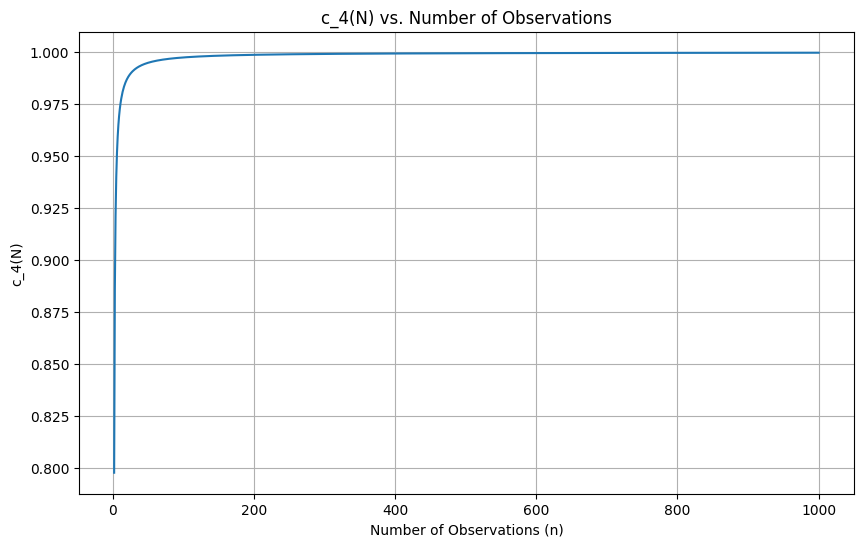

In [109]:
# Plot the graph of c_4(N): sqrt(2/(n - 1)) * gamma(n/2) / gamma((n - 1)/2) versus n
n_values = np.arange(2, 1001)
gamma_ratio = np.sqrt(2 / (n_values - 1)) * np.exp(
    np.array([math.lgamma(n / 2) - math.lgamma((n - 1) / 2)  for n in n_values])
)
plt.figure(figsize=(10, 6))
plt.plot(n_values, gamma_ratio, label=r'$c_4(N) = \sqrt{\frac{2}{n - 1}} \cdot \frac{\Gamma(n/2)}{\Gamma((n - 1)/2)} - 1$')
plt.title('c_4(N) vs. Number of Observations')
plt.xlabel('Number of Observations (n)')
plt.ylabel('c_4(N)')
plt.grid()

In [107]:
## Verifying the computation above
true_mu = 0.1
true_sigma = 0.2
n_observations = 1000 
paths = generate_gbm_paths(S0=1, mu=true_mu, sigma=true_sigma, T=1, N=n_observations, M=1000, mesh_size=1e-4)
estimated_mu, estimated_sigma = path_wise_gbm_parameter_estimation(paths, T=1)
var_estimated_mu = np.var(estimated_mu)
var_estimated_sigma = np.var(estimated_sigma)
print(f"Variance of estimated μ: {var_estimated_mu}")
print(f"Variance of estimated σ: {var_estimated_sigma}")
theoretical_var_mu = (true_sigma**2) + true_sigma**4/(2 * (n_observations - 1))
c4_coefficient = np.sqrt(2 / (n_observations - 1)) * np.exp(
    math.lgamma(n_observations / 2) - math.lgamma((n_observations - 1) / 2)
)
theoretical_var_sigma = (true_sigma**2) * (1 - c4_coefficient**2)
print(f"Theoretical variance of estimated μ: {theoretical_var_mu}")
print(f"Theoretical variance of estimated σ: {theoretical_var_sigma}")

# Calculate the rate of error versus the observed value
error_mu = np.abs(var_estimated_mu - theoretical_var_mu) / theoretical_var_mu
error_sigma = np.abs(var_estimated_sigma - theoretical_var_sigma) / theoretical_var_sigma
print(f"Mean relative error of μ: {np.mean(error_mu)}"
      f"\nMean relative error of σ: {np.mean(error_sigma)}")

Variance of estimated μ: 0.03789329380270363
Variance of estimated σ: 1.9405365465653967e-05
Theoretical variance of estimated μ: 0.04000080080080081
Theoretical variance of estimated σ: 2.001500748526564e-05
Mean relative error of μ: 0.052686620165239076
Mean relative error of σ: 0.030459245146946347
